In [29]:
import os
from pathlib import Path
import pandas as pd
import muon as mu
import numpy as np

import torch
import torch.nn as nn

In [2]:
mm10_gene_info_df = pd.read_csv(
    "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/genome_data/genome_annotation/mm10/Mus_musculus.gene_info.gz", 
    sep="\t", compression="gzip", header=0)
mm10_gene_info_df.head()

,#tax_id,GeneID,Symbol,LocusTag,Synonyms,dbXrefs,chromosome,map_location,description,type_of_gene,Symbol_from_nomenclature_authority,Full_name_from_nomenclature_authority,Nomenclature_status,Other_designations,Modification_date,Feature_type
0,10090,11287,Pzp2,-,A1m|A2m|MAM|Pzp,MGI:MGI:87854|Ensembl:ENSMUSG00000030359|Allia...,6,6 F3|6 63.02 cM,PZP alpha-2-macroglobulin like 2,protein-coding,Pzp2,PZP alpha-2-macroglobulin like 2,O,"pregnancy zone protein|PZP, alpha-2-macroglobu...",20250924,-
1,10090,11298,Aanat,-,AA-NAT|Nat-2|Nat4|Snat,MGI:MGI:1328365|Ensembl:ENSMUSG00000020804|All...,11,11 81.43 cM|11 E2,arylalkylamine N-acetyltransferase,protein-coding,Aanat,arylalkylamine N-acetyltransferase,O,serotonin N-acetyltransferase|aralkylamine N-a...,20250930,-
2,10090,11302,Aatk,-,AATYK|aatyk1|mKIAA0641,MGI:MGI:1197518|Ensembl:ENSMUSG00000025375|All...,11,11 E2|11 83.96 cM,apoptosis-associated tyrosine kinase,protein-coding,Aatk,apoptosis-associated tyrosine kinase,O,serine/threonine-protein kinase LMTK1|apoptosi...,20250924,-
3,10090,11303,Abca1,-,ABC-1|Abc1,MGI:MGI:99607|Ensembl:ENSMUSG00000015243|Allia...,4,4 B2|4 28.57 cM,"ATP-binding cassette, sub-family A member 1",protein-coding,Abca1,"ATP-binding cassette, sub-family A member 1",O,phospholipid-transporting ATPase ABCA1|ATP-bin...,20250930,-
4,10090,11304,Abca4,-,Abc10|Abcr|D430003I15Rik|RmP,MGI:MGI:109424|Ensembl:ENSMUSG00000028125|Alli...,3,3 G1|3 52.94 cM,"ATP-binding cassette, sub-family A member 4",protein-coding,Abca4,"ATP-binding cassette, sub-family A member 4",O,retinal-specific phospholipid-transporting ATP...,20250924,-


In [3]:
gene_tss_df = pd.read_csv(
    "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/genome_data/genome_annotation/mm10/mm10_gene_tss.bed", 
    sep="\t", names=["chr", "start", "end", "Symbol"])
gene_tss_df.head()

,chr,start,end,Symbol
0,chrY,31419544,31419545,Gm28489
1,chrY,68409633,68409634,Gm21867
2,chrY,68446562,68446563,Gm29448
3,chrY,68549224,68549225,Gm20816
4,chrY,68550741,68550742,Gm20816


In [4]:
mdata = mu.read(
    "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mESC/E7.5_rep1/multiome_processed.h5mu"
    )
mdata

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 6832 × 215552
  var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
  2 modalities
    rna:	6832 x 18637
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'celltype'
      var:	'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'celltype_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'log1p', 'neighbors', 'pca', 'scrublet', 'tsne', 'umap'
      obsm:	'X_pca', 'X_tsne', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    atac:	6832 x 196915
      obs:	'n_genes_by_counts', 'total_counts', 'outlier', 'NS', 'n_counts', 'leiden'
      var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'nearest_gene', 'TSS_dist', 'TSS_dist_score'
      uns:	'files', 'leiden', 'leiden_colors', 'log1p', 'lsi', 'neighbors', 'pca', 'peak_gene_distance_params', 'peak_gene_links', 'umap'
      obsm:	'X_lsi', 'X_pca', 'X_umap'
      varm:	'LSI', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

In [ ]:
mm10_genes_sorted = mm10_gene_info_df["Symbol"].dropna().astype(str).drop_duplicates().sort_values().to_list()

PAD_IDX = 0 # All genes that need padding are given to padding vector (initialized as 0's, no gradient updates)
UNK_IDX = 1 # All unknown genes get mapped to the same "unknown" vector

# Create an ordered mapping of all mouse genes
gene_idx_map = {gene: idx + 2 for idx, gene in enumerate(mm10_genes_sorted)}


In [ ]:

def get_gene_information(mdata, gene_idx_map):
    """
    Extracts gene expression data and cell type labels from a MuData object.

    Parameters:
    - mdata: MuData object containing multi-omics data.
    - gene_idx_map: Dictionary mapping gene names to their corresponding indices.

    Returns:
    - gene_expr_tensor: Tensor containing gene expression data for known genes.
    - rna_gene_indices: Tensor containing indices of known genes in the RNA modality.
    - cell_labels: Tensor containing integer codes for each cell's cell type.
    - idx_class_map: Dictionary mapping class integer codes to cell type names.
    """

    # Get the genes from the RNA modality of the MuData object
    rna_genes = mdata.mod["rna"].var_names.astype(str).tolist()

    # Get the column indices for genes in gene_idx_map (used to track gene expression)
    known_gene_mask = np.array([gene in gene_idx_map for gene in rna_genes])
    known_gene_positions = np.flatnonzero(known_gene_mask)

    # Get the mapped indices for the known genes in the RNA modality (used to track gene embeddings)
    matched_genes = [gene for gene, known in zip(rna_genes, known_gene_mask) if known]
    rna_gene_indices = torch.tensor([gene_idx_map.get(gene, UNK_IDX) for gene in matched_genes], dtype=torch.long)

    # Convert the gene expression into a dense tensor
    gene_expr = mdata.mod["rna"].X.copy()
    gene_expr_dense = gene_expr.todense() if hasattr(gene_expr, "todense") else gene_expr
    gene_expr_tensor = torch.tensor(gene_expr_dense, dtype=torch.float32)

    # Subset the expression tensor to genes with embeddings
    gene_expr_tensor = gene_expr_tensor[:, known_gene_positions] 

    assert gene_expr_tensor.shape[1] == len(matched_genes)
    assert gene_expr_tensor.shape[1] == len(rna_gene_indices)
    
    # Get the cell types from the RNA modality
    celltypes = mdata.mod["rna"].obs["celltype"].astype("category")

    # Get the integer code for each cell's cell type
    cell_labels = torch.tensor(
        celltypes.cat.codes.to_numpy(),
        dtype=torch.long,
    )

    # Map the class integer codes to the cell type names
    classes = celltypes.cat.categories.tolist()
    idx_class_map = {
        idx: class_name
        for idx, class_name in enumerate(classes)
    }
    
    return {
        "gene_expr_tensor": gene_expr_tensor,
        "rna_gene_indices": rna_gene_indices,
        "cell_labels": cell_labels,
        "idx_class_map": idx_class_map
    }

e75_rep1_mdata = mu.read(
    "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mESC/E7.5_rep1/multiome_processed.h5mu"
    )

e75_rep1_input_info = get_gene_information(e75_rep1_mdata, gene_idx_map)

In [ ]:
import torch.nn.functional as F

# Create Fully Connected Network
class GeneExpressionModel(nn.Module):
    def __init__(
        self, 
        num_gene_embeddings, 
        dataset_gene_indices, 
        embedding_dim=128, 
        hidden_dim=256,
        output_dim=10,
        pad_idx=0
        ): # (28x28 images = 724)
        super(GeneExpressionModel, self).__init__() # Calls the initialization method of nn.Module

        self.gene_emb = nn.Embedding(
            num_embeddings=num_gene_embeddings,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx,
        )
        
        # These indices describe the fixed columns of the expression matrix.
        # They move with the model but are not trainable parameters.
        self.register_buffer(
            "dataset_gene_indices",
            dataset_gene_indices.clone().long(),
        )
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, output_dim),
        )
        
    def forward(self, gene_expression):
        # Get gene embeddings for the dataset genes
        gene_embeddings = self.gene_emb(
            self.dataset_gene_indices
            )  # [batch_size, num_genes, embedding_dim]
        
        # Convert expression into per-cell gene weights
        expression_weights = gene_expression / gene_expression.sum(dim=1, keepdim=True).clamp_min(1e-8)
        
        # Multiply the cell expression weights by the gene embeddings to get a single embedding per cell
        cell_embeddings = expression_weights @ gene_embeddings  # [batch_size, embedding_dim]
        
        output = self.classifier(cell_embeddings)
        
        return output

model = GeneExpressionModel(
    num_gene_embeddings=len(gene_idx_map) + 2,
    dataset_gene_indices=e75_rep1_input_info["rna_gene_indices"],
    embedding_dim=128,
    hidden_dim=256,
    output_dim=len(e75_rep1_input_info["idx_class_map"]),
    pad_idx=PAD_IDX,
)


In [48]:
from torch.utils.data import DataLoader, TensorDataset


def check_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for expression_batch, label_batch in data_loader:
            expression_batch = expression_batch.to(device)
            label_batch = label_batch.to(device)
            outputs = model(expression_batch)
            _, predicted = torch.max(outputs.data, 1)
            total += label_batch.size(0)
            correct += (predicted == label_batch).sum().item()
    model.train()
    return 100 * correct / total

num_epochs = 10

# 80% train, 20% test splits
train_indices, test_indices = torch.randperm(len(gene_expr_tensor)).split(int(0.8 * len(gene_expr_tensor)))

train_dataset = TensorDataset(
    gene_expr_tensor[train_indices],
    cell_labels[train_indices]
)

test_dataset = TensorDataset(
    gene_expr_tensor[test_indices],
    cell_labels[test_indices]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

criterion = nn.CrossEntropyLoss()

print("Training...")
model.train()
for epoch in range(num_epochs):
    for expression_batch, label_batch in train_loader:
        expression_batch = expression_batch.to(device)
        label_batch = label_batch.to(device)

        optimizer.zero_grad()

        logits = model(expression_batch)
        loss = criterion(logits, label_batch)

        loss.backward()
        optimizer.step()
        
    train_accuracy = check_accuracy(model, train_loader, device)
    test_accuracy = check_accuracy(model, test_loader, device)
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}, Train Accuracy: {train_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")


Training...
Epoch 1/10, Loss: 1.1618, Train Accuracy: 72.63%, Test Accuracy: 67.30%
Epoch 2/10, Loss: 0.8662, Train Accuracy: 82.67%, Test Accuracy: 72.42%
Epoch 3/10, Loss: 0.9312, Train Accuracy: 88.98%, Test Accuracy: 73.15%
Epoch 4/10, Loss: 0.3867, Train Accuracy: 94.66%, Test Accuracy: 74.32%
Epoch 5/10, Loss: 0.4194, Train Accuracy: 97.26%, Test Accuracy: 75.20%
Epoch 6/10, Loss: 0.3066, Train Accuracy: 98.99%, Test Accuracy: 74.62%
Epoch 7/10, Loss: 0.0851, Train Accuracy: 99.63%, Test Accuracy: 74.18%
Epoch 8/10, Loss: 0.0259, Train Accuracy: 99.95%, Test Accuracy: 73.81%
Epoch 9/10, Loss: 0.0173, Train Accuracy: 99.91%, Test Accuracy: 73.74%
Epoch 10/10, Loss: 0.0227, Train Accuracy: 99.96%, Test Accuracy: 74.69%


In [ ]:
# Use the model to predict cell types for all cells in the dataset
model.eval()
with torch.no_grad():
    all_outputs = model(gene_expr_tensor.to(device))
    _, all_predictions = torch.max(all_outputs.data, 1)
    
# Map the predicted integer codes back to cell type names
predicted_cell_types = [idx_class_map[idx.item()] for idx in all_predictions]

rna = mdata.mod["rna"].copy()
rna.obs["predicted_celltype"] = predicted_cell_types

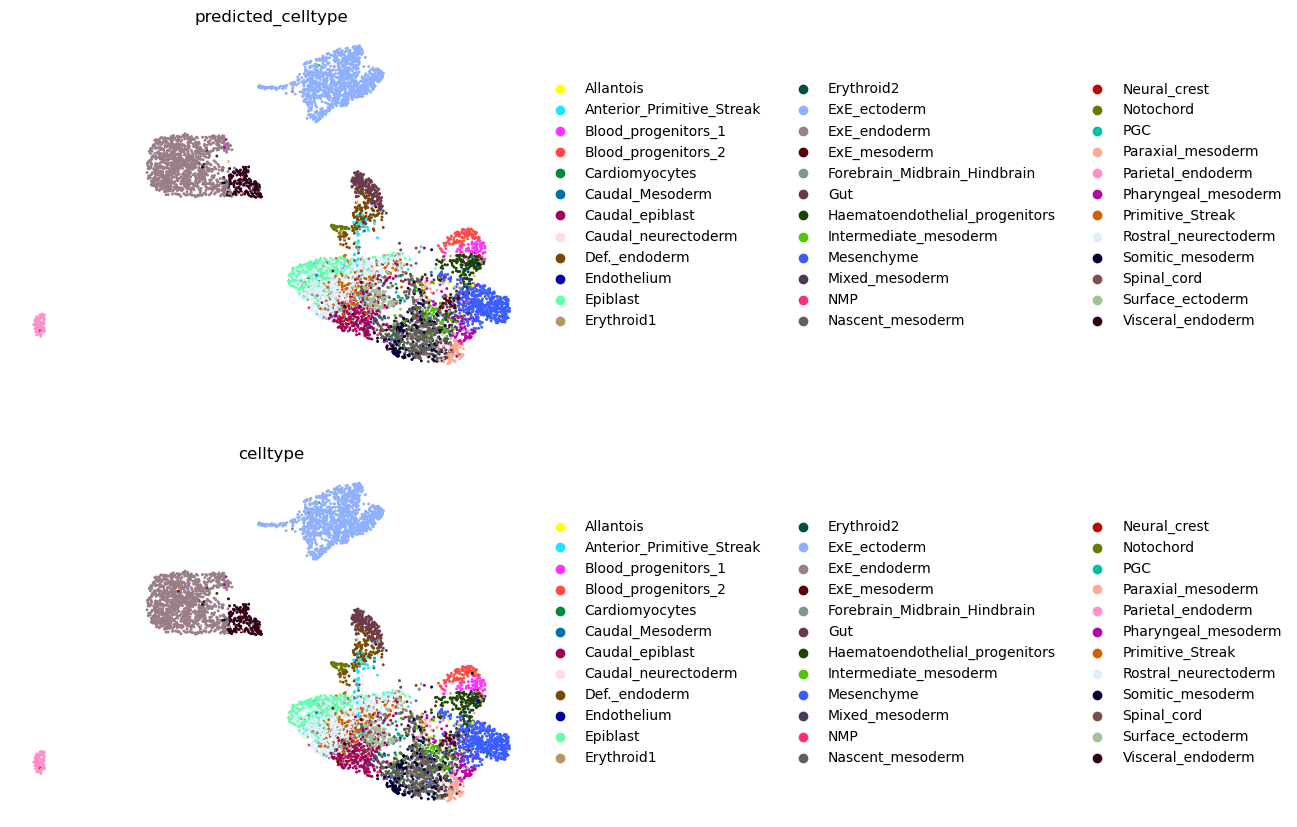

In [52]:
import scanpy as sc

sc.pl.umap(
    rna,
    color=["predicted_celltype", "celltype"],
    vmax="p99",
    frameon=False,
    ncols=1
)